In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data_missing_value_imputation.csv')

In [4]:
latlong = pd.read_csv(r'D:\vs code projects\rental_analysis\app\latlong.csv')

In [5]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [6]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [7]:
new_df = df.merge(latlong, on='sector')

In [8]:
new_df.dtypes

property_type          str
society                str
sector                 str
price              float64
price_per_sqft     float64
bedRoom              int64
bathroom             int64
balcony                str
floorNum           float64
agePossession          str
built_up_area      float64
study room           int64
servant room         int64
store room           int64
pooja room           int64
others               int64
furnishing_type      int64
luxury_score         int64
coordinates            str
latitude           float64
longitude          float64
dtype: object

In [9]:
group_df = new_df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean()

In [10]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.966562,4656.968750,2019.700000,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.681327,10641.053097,1545.486726,28.4750,76.9715
sector 103,1.441556,7424.555556,1804.533333,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.931346,5906.298077,1574.492115,28.4079,76.9153
sector 93,0.808182,8516.363636,941.272727,28.4153,76.9326
sector 95,0.486610,5595.305085,1011.694915,28.4172,76.9081


In [11]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\msi 1\AppData\Local\Temp\ipykernel_16796\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [12]:
new_df.to_csv(r'D:\vs code projects\rental_analysis\app\data_viz1.csv',index=False)

In [20]:
df1 = pd.read_csv(r'D:\vs code projects\rental_analysis\data\raw\Gurugram\Flats\flats.csv')
df1.head()

,property_name,link,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
0,2 BHK Flat in Krishna Colony,https://www.99acres.com/2-bhk-bedroom-apartmen...,maa bhagwati residency,45 Lac,"₹ 5,000/sq.ft.",Carpet area: 900 (83.61 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"Krishna Colony, Gurgaon, Haryana",4th of 4 Floors,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",C68850746
1,2 BHK Flat in Ashok Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Apna Enclave,50 Lac,"₹ 7,692/sq.ft.",Carpet area: 650 (60.39 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"46b, Ashok Vihar, Gurgaon, Haryana",1st of 3 Floors,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",H68850564
2,2 BHK Flat in Sohna,https://www.99acres.com/2-bhk-bedroom-apartmen...,Tulsiani Easy in Homes,40 Lac,"₹ 6,722/sq.ft.",Carpet area: 595 (55.28 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,NaN,"Sohna, Gurgaon, Haryana",12nd of 14 Floors,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...","This property is 15 km away from badshapur, gu...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",J68850120
3,2 BHK Flat in Sector 61 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Smart World Orchard,1.47 Crore,"₹ 12,250/sq.ft.",Carpet area: 1200 (111.48 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,Study Room,"Sector 61 Gurgaon, Gurgaon, Haryana",2nd of 4 Floors,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",Near to metro station of sector 56 and opposit...,NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,S68849476
4,2 BHK Flat in Sector 92 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Parkwood Westend,70 Lac,"₹ 5,204/sq.ft.",Super Built up area 1345(124.95 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,Study Room,"Sector 92 Gurgaon, Gurgaon, Haryana",5th of 8 Floors,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",We are the proud owners of this 2 bhk alongwit...,[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",L47956793


In [21]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [61]:
wordcloud_df

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 79
1,"['Security / Fire Alarm', 'Maintenance Staff',...",sector 79
2,"['Power Back-up', 'Feng Shui / Vaastu Complian...",sector 60
3,"['Security / Fire Alarm', 'Private Garden / Te...",sohna road
4,NaN,sector 113
...,...,...
3023,NaN,sector 90
3024,"['Security / Fire Alarm', 'Private Garden / Te...",sector 70
3025,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 72
3026,"['Security / Fire Alarm', 'Private Garden / Te...",sector 104


In [32]:
wordcloud_df=wordcloud_df[wordcloud_df['features']!='features']

In [33]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [34]:
from wordcloud import WordCloud

feature_text = ' '.join(main)

In [35]:
import pickle
pickle.dump(feature_text, open(r'D:\vs code projects\rental_analysis\app\feature_text.pkl','wb'))

In [36]:
feature_text

'Feng Shui / Vaastu Compliant Security / Fire Alarm Lift(s) Water Storage Visitor Parking Security / Fire Alarm Maintenance Staff Water Storage Park Visitor Parking Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Swimming Pool Park Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Private Garden / Terrace Lift(s) Maintenance Staff False Ceiling Lighting Water Storage Visitor Parking Swimming Pool Natural Light Airy Rooms Fitness Centre / GYM Club house / Community Center Water softening plant Power Back-up Intercom Facility Lift(s) Swimming Pool Maintenance Staff Park Security Personnel Internet/wi-fi connectivity Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Water softening plant Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Swimming Pool Park Security Personnel Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Security / Fire Alarm Intercom Facility Lift(s) Mainten

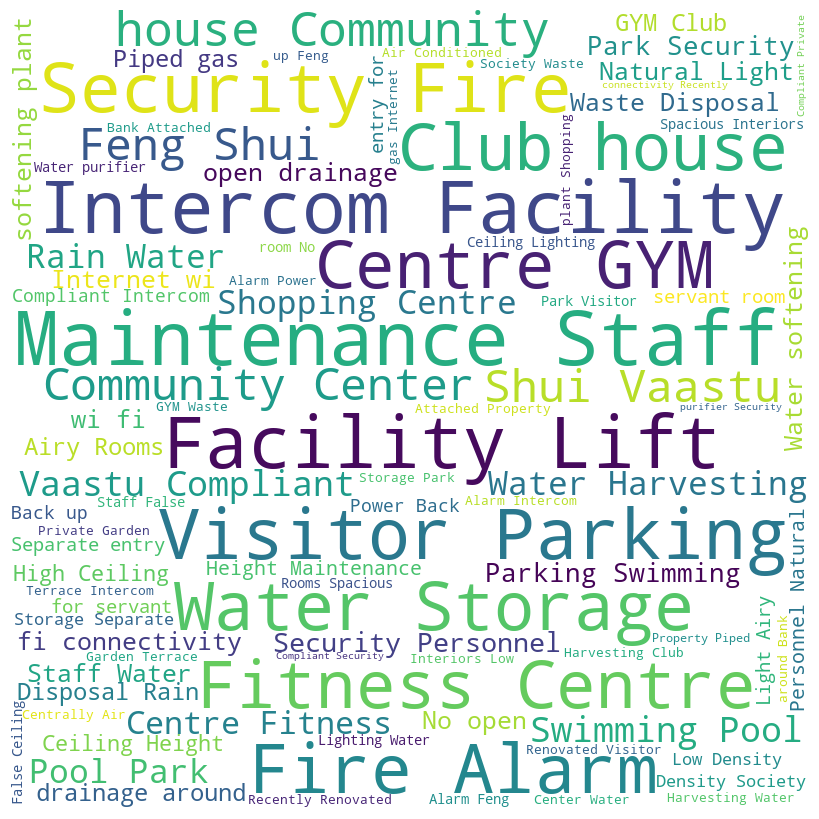

In [ ]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [60]:
wordcloud_df[(wordcloud_df['features'].notna() ) & (wordcloud_df['sector']=='sector 79')]

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 79
1,"['Security / Fire Alarm', 'Maintenance Staff',...",sector 79
195,"['Maintenance Staff', 'Swimming Pool', 'Park']",sector 79
232,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 79
239,"['Intercom Facility', 'Lift(s)', 'Swimming Poo...",sector 79
262,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",sector 79
263,"['Centrally Air Conditioned', 'Security / Fire...",sector 79
271,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",sector 79
356,"['Intercom Facility', 'Lift(s)', 'Swimming Poo...",sector 79
374,"['Centrally Air Conditioned', 'Water purifier'...",sector 79


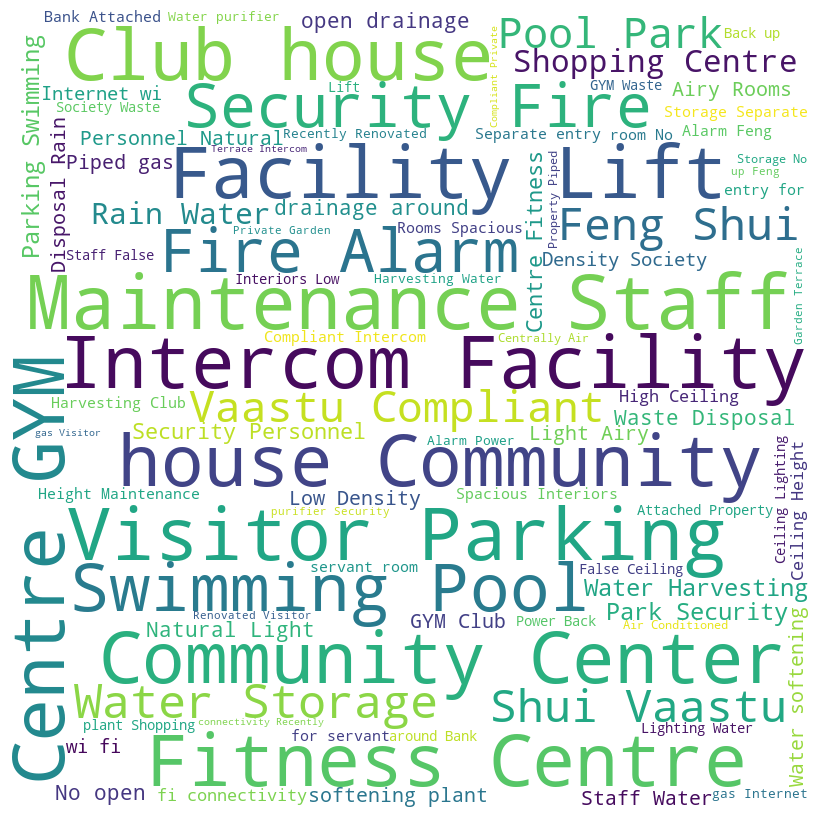

Feng Shui / Vaastu Compliant Security / Fire Alarm Lift(s) Water Storage Visitor Parking Security / Fire Alarm Maintenance Staff Water Storage Park Visitor Parking Maintenance Staff Swimming Pool Park Security / Fire Alarm Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Centrally Air Conditioned Maintenance Staff Water Storage No open drainage around Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natural Light Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water softening plant Intercom Facility Lift(s) Swimming Pool Security Personnel Maintenance Staff Park Club house / Community Center Fitness Centre / GYM Shopping Centre Rain Water Harvesting Security / Fire Alarm Lift(s) Maintenance Staff Water Storage Separate entry for servant room No open drainage around Visitor Parking Swimming Pool Park Natural Light Airy Rooms Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Security /

In [ ]:
from wordcloud import WordCloud
def wordcloud_bysector(sector):
   import ast
   main = []
   for item in wordcloud_df[(wordcloud_df['features'].notna() ) & (wordcloud_df['sector']==sector)]['features'].dropna().apply(ast.literal_eval):
     main.extend(item)

   feature_text = ' '.join(main)
   plt.rcParams["font.family"] = "Arial"

   wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

   plt.figure(figsize = (8, 8), facecolor = None) 
   plt.imshow(wordcloud, interpolation='bilinear') 
   plt.axis("off") 
   plt.tight_layout(pad = 0) 
   plt.show()
   #print(feature_text)

wordcloud_bysector('sector 79')  

In [62]:
import pickle
wordcloud_df.to_csv(r'D:\vs code projects\rental_analysis\app\wordcloud.csv')

In [39]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [40]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [41]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

<Axes: xlabel='price', ylabel='Count'>

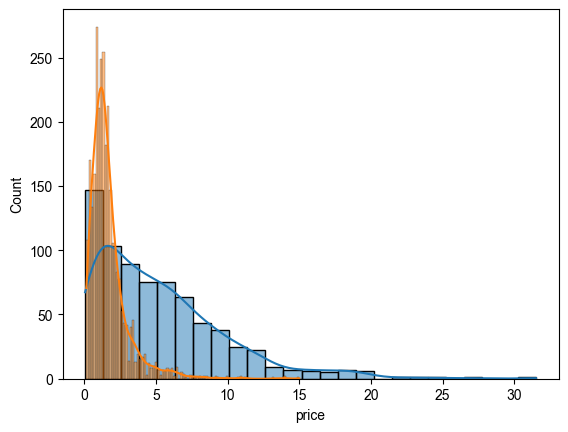

In [42]:
sns.histplot(df[df['property_type'] == 'house']['price'],kde=True)
sns.histplot(df[df['property_type'] == 'flat']['price'],kde=True)